# Main Imports

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from matplotlib.ticker import MultipleLocator
import re
import os
import numpy as np

# import data
cb_10x = os.path.join("..", "..", "..", "se", "new", "clean-files-ul", "aggr", "agg-cb-10.csv")
cf_10x_aggr = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cf-10-agg.csv")
cf_10x = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cf-10.csv")
cb_5x = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cb-5.csv")
cf_5x_aggr = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cf-5-agg.csv")
cf_5x = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cf-5.csv")
cf_1x_aggr = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cf-1-agg.csv")
cb_1x = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cb-1.csv")
cf_1x = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cf-1.csv")

# Calculations for every file

#### 1x Scenarios

In [33]:
# Read content of the file
df_cb_1 = pd.read_csv(cb_1x)
df_cf_1 = pd.read_csv(cf_1x)
df_cf_1_aggr = pd.read_csv(cf_1x_aggr)

In [34]:
def read_data_by_ue(csv_path): 
  df = pd.read_csv(csv_path)

  dfs = {}

  for ue_id, group in df.groupby("UE_ID"):
    df_ue = group.sort_values("Time_ms").reset_index(drop=True)
    df_ue["Rolling Avg (bit/s/Hz)"] = df_ue["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5, min_periods=1).mean()
    dfs[ue_id] = df_ue
  
  return dfs

dfs_cb_1 = read_data_by_ue(cb_1x)
dfs_cf_1 = read_data_by_ue(cf_1x)
dfs_cf_1_aggr = read_data_by_ue(cf_1x_aggr)

#### 5x Scenarios

In [47]:
def read_data_by_ue(csv_path): 
  df = pd.read_csv(csv_path)

  dfs = {}

  for ue_id, group in df.groupby("UE_ID"):
    df_ue = group.sort_values("Time_ms").reset_index(drop=True)
    df_ue["Rolling Avg (bit/s/Hz)"] = df_ue["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5, min_periods=1).mean()
    dfs[ue_id] = df_ue
  
  return dfs

dfs_cb_5 = read_data_by_ue(cb_5x)
dfs_cf_5 = read_data_by_ue(cf_5x)
dfs_cf_5_aggr = read_data_by_ue(cf_5x_aggr)

#### 10x Scenarios

In [42]:
def read_data_by_ue(csv_path): 
  df = pd.read_csv(csv_path)

  dfs = {}

  for ue_id, group in df.groupby("UE_ID"):
    df_ue = group.sort_values("Time_ms").reset_index(drop=True)
    df_ue["Rolling Avg (bit/s/Hz)"] = df_ue["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5, min_periods=1).mean()
    dfs[ue_id] = df_ue
  
  return dfs

dfs_cb_10 = read_data_by_ue(cb_10x)
dfs_cf_10 = read_data_by_ue(cf_10x)
dfs_cf_10_aggr = read_data_by_ue(cf_10x_aggr)

# Behavior Graphics 

## 1X Scenarios

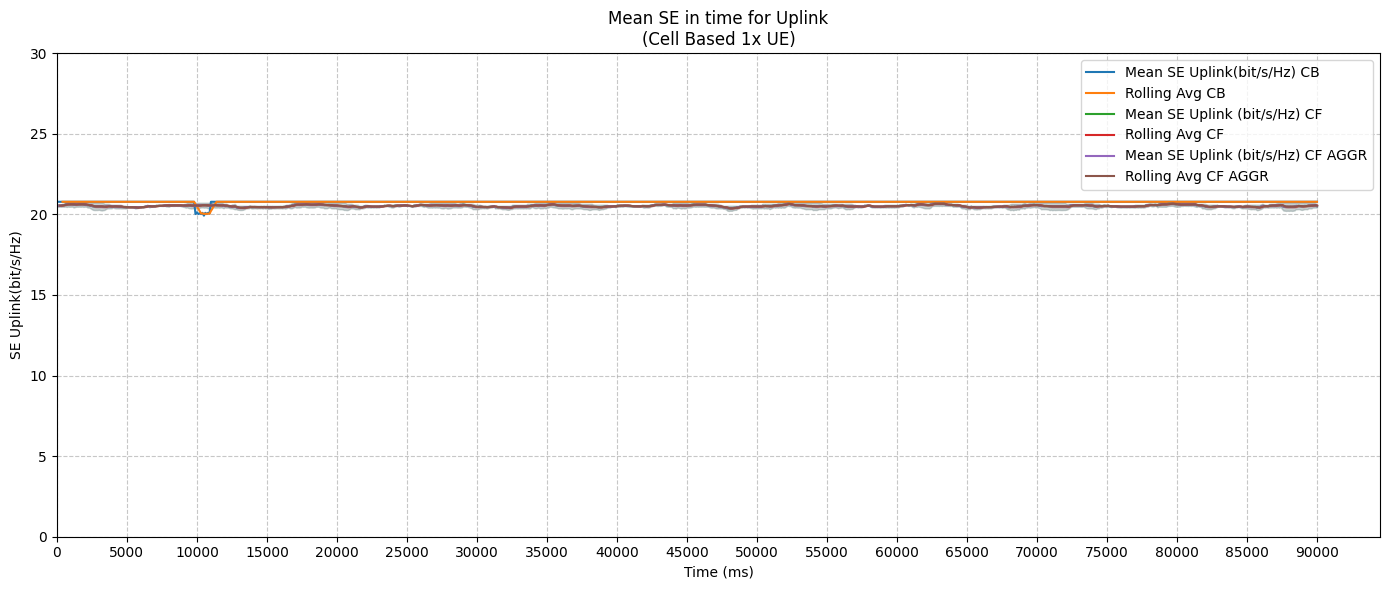

In [36]:
df_cb_1["Mean_UL_SE_bit_per_s_Hz"] = df_cb_1["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cb_1["Rolling Avg (bit/s/Hz)"] = df_cb_1["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

df_cf_1["Mean_UL_SE_bit_per_s_Hz"] = df_cf_1["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cf_1["Rolling Avg (bit/s/Hz)"] = df_cf_1["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

df_cf_1_aggr["Mean_UL_SE_bit_per_s_Hz"] = df_cf_1_aggr["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cf_1_aggr["Rolling Avg (bit/s/Hz)"] = df_cf_1_aggr["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

plt.figure(figsize=(14, 6))
sns.lineplot(x="Time_ms", y="Mean_UL_SE_bit_per_s_Hz", data=df_cb_1, label="Mean SE Uplink(bit/s/Hz) CB")
sns.lineplot(x="Time_ms", y="Rolling Avg (bit/s/Hz)", data=df_cb_1, label="Rolling Avg CB")
sns.lineplot(x="Time_ms", y="Mean_UL_SE_bit_per_s_Hz", data=df_cf_1, label="Mean SE Uplink (bit/s/Hz) CF")
sns.lineplot(x="Time_ms", y="Rolling Avg (bit/s/Hz)", data=df_cf_1, label="Rolling Avg CF")
sns.lineplot(x="Time_ms", y="Mean_UL_SE_bit_per_s_Hz", data=df_cf_1, label="Mean SE Uplink (bit/s/Hz) CF AGGR")
sns.lineplot(x="Time_ms", y="Rolling Avg (bit/s/Hz)", data=df_cf_1, label="Rolling Avg CF AGGR")
plt.title("Mean SE in time for Uplink\n(Cell Based 1x UE)")
plt.xlabel("Time (ms)")
plt.ylabel("SE Uplink(bit/s/Hz)")
plt.legend()
plt.ylim(0, 30)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [37]:
print(df_cb_1["Mean_UL_SE_bit_per_s_Hz"].describe())
print(df_cf_1["Mean_UL_SE_bit_per_s_Hz"].describe())
print(df_cf_1_aggr["Mean_UL_SE_bit_per_s_Hz"].describe())

count    899.000000
mean      20.769041
std        0.080766
min       19.917000
25%       20.778000
50%       20.778000
75%       20.778000
max       20.778000
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64
count    1802.000000
mean       20.521447
std         0.139151
min        20.211000
25%        20.417000
50%        20.530000
75%        20.654000
max        20.778000
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64
count    901.000000
mean      28.598391
std        0.064920
min       27.638000
25%       28.565000
50%       28.600000
75%       28.637000
max       28.720000
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64


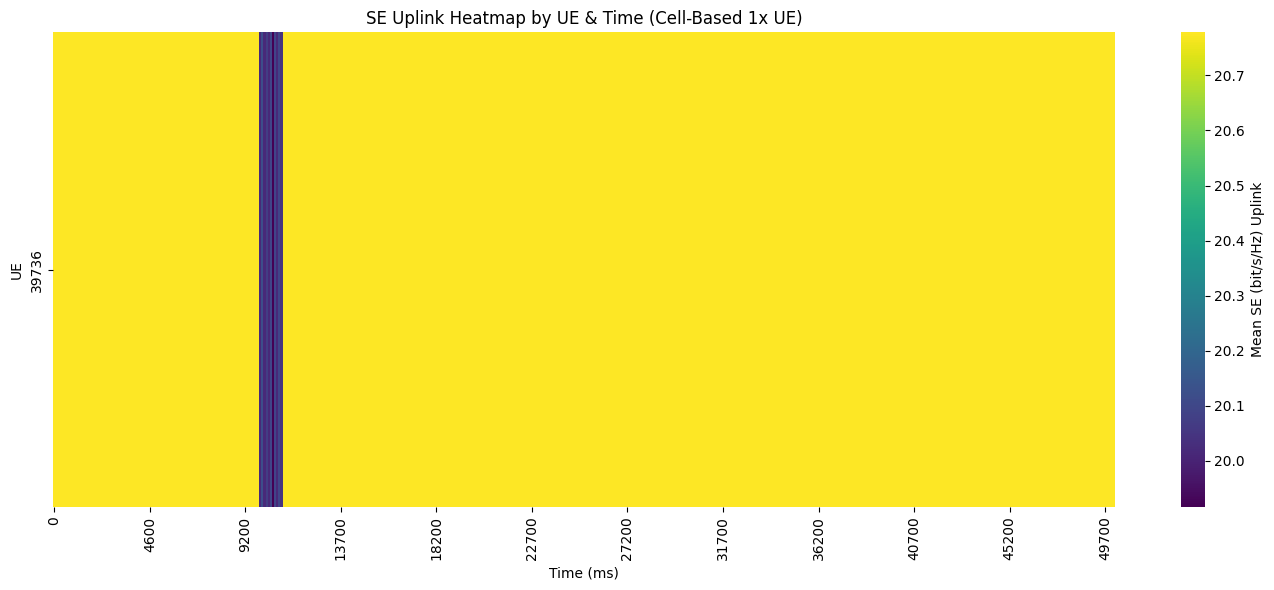

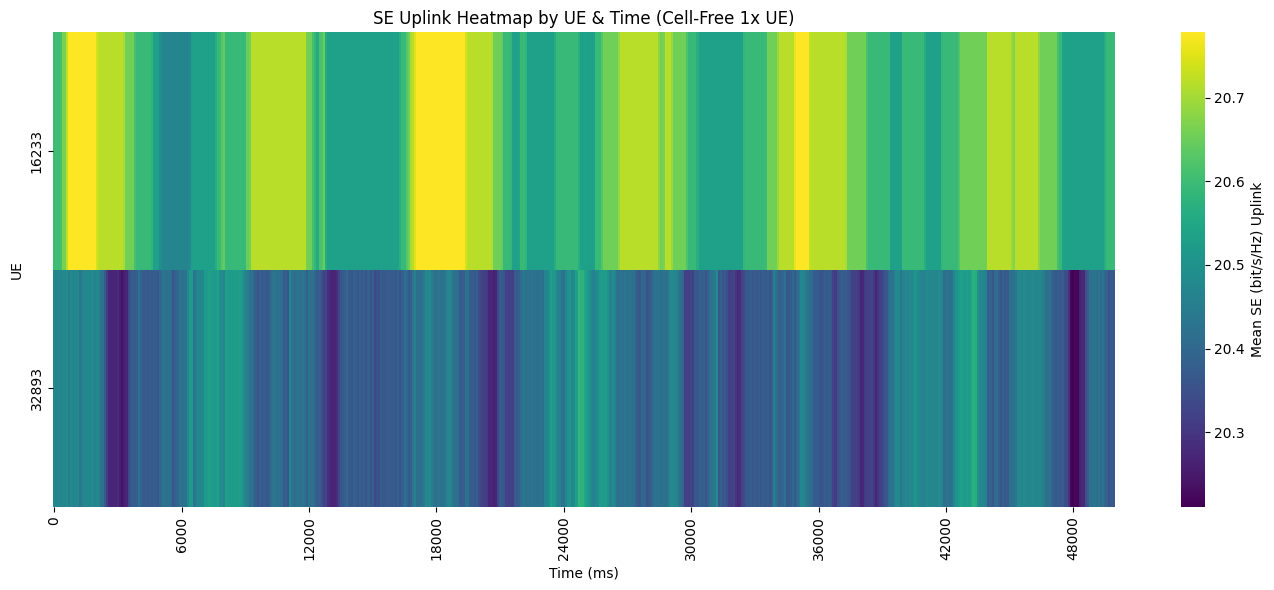

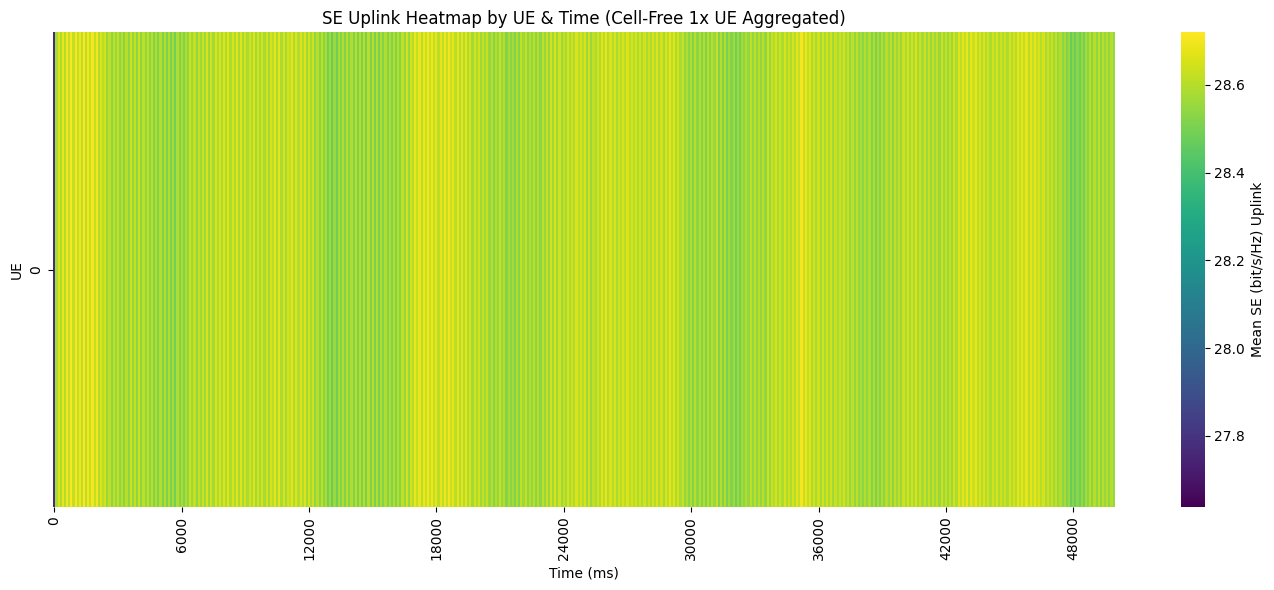

In [39]:
heat_cb = df_cb_1.pivot(index="UE_ID", columns="Time_ms", values="Mean_UL_SE_bit_per_s_Hz")
heat_cf = df_cf_1.pivot(index="UE_ID", columns="Time_ms", values="Mean_UL_SE_bit_per_s_Hz")
heat_cf_aggr = df_cf_1_aggr.pivot(index="UE_ID", columns="Time_ms", values="Mean_UL_SE_bit_per_s_Hz")

# Plot Cell-Based
plt.figure(figsize=(14, 6))
sns.heatmap(heat_cb, cmap="viridis", cbar_kws={'label': 'Mean SE (bit/s/Hz) Uplink'})
plt.title("SE Uplink Heatmap by UE & Time (Cell-Based 1x UE)")
plt.xlabel("Time (ms)")
plt.locator_params(axis="x", nbins=20)
plt.ylabel("UE")
plt.tight_layout()
plt.xlim(0,500)
plt.show()

# Plot Cell-Free
plt.figure(figsize=(14, 6))
sns.heatmap(heat_cf, cmap="viridis", cbar_kws={'label': 'Mean SE (bit/s/Hz) Uplink'})
plt.title("SE Uplink Heatmap by UE & Time (Cell-Free 1x UE)")
plt.xlabel("Time (ms)")
plt.locator_params(axis="x", nbins=20)
plt.ylabel("UE")
plt.xlim(0,500)
plt.tight_layout()
plt.show()

# Plot Cell-Free
plt.figure(figsize=(14, 6))
sns.heatmap(heat_cf_aggr, cmap="viridis", cbar_kws={'label': 'Mean SE (bit/s/Hz) Uplink'})
plt.title("SE Uplink Heatmap by UE & Time (Cell-Free 1x UE Aggregated)")
plt.xlabel("Time (ms)")
plt.locator_params(axis="x", nbins=20)
plt.ylabel("UE")
plt.xlim(0,500)
plt.tight_layout()
plt.show()

## 5X Scenarios

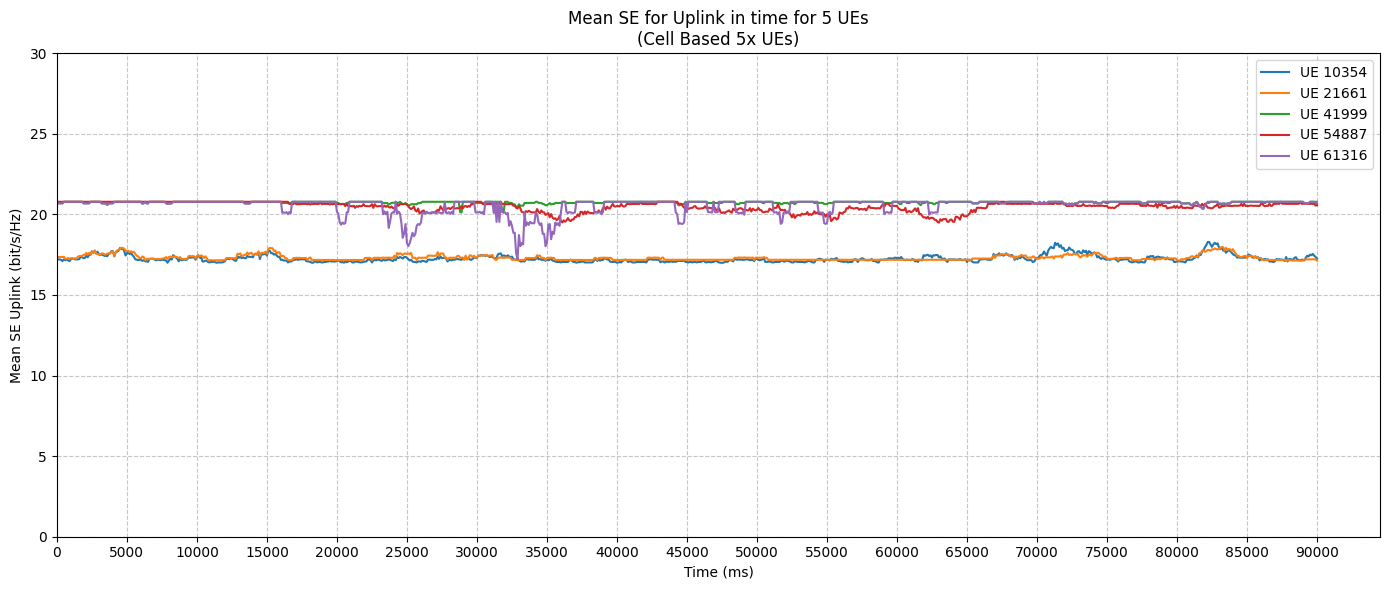

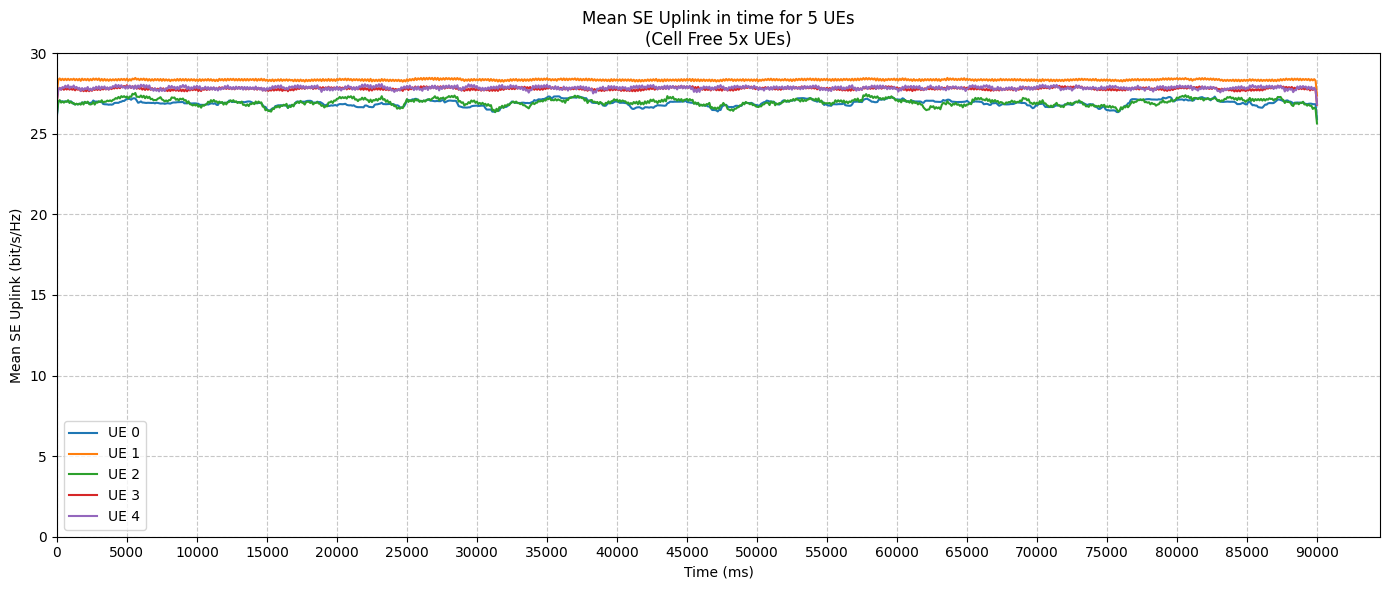

In [49]:
plt.figure(figsize=(14, 6))
for ue, df in dfs_cb_5.items():
    dfs_cb_5[ue]["Mean_UL_SE_bit_per_s_Hz"] = dfs_cb_5[ue]["Mean_UL_SE_bit_per_s_Hz"].round(3)

    sns.lineplot(x="Time_ms", y="Mean_UL_SE_bit_per_s_Hz", data=df, label=f"UE {ue}")

plt.title("Mean SE for Uplink in time for 5 UEs\n(Cell Based 5x UEs)")
plt.xlabel("Time (ms)")
plt.ylabel("Mean SE Uplink (bit/s/Hz)")
plt.grid(True)
plt.legend()

plt.ylim(0, 30)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 6))
for ue, df in dfs_cf_5_aggr.items():
    dfs_cf_5_aggr[ue]["Mean_UL_SE_bit_per_s_Hz"] = dfs_cf_5_aggr[ue]["Mean_UL_SE_bit_per_s_Hz"].round(3)
    sns.lineplot(x="Time_ms", y="Mean_UL_SE_bit_per_s_Hz", data=df, label=f"UE {ue}")
plt.title("Mean SE Uplink in time for 5 UEs\n(Cell Free 5x UEs)")
plt.xlabel("Time (ms)")
plt.ylabel("Mean SE Uplink (bit/s/Hz)")
plt.grid(True)
plt.legend()

plt.ylim(0, 30)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [50]:
df_cb_5 = pd.read_csv(cb_5x)
df_cf_5 = pd.read_csv(cf_5x)
df_cf_5_aggr = pd.read_csv(cf_5x_aggr)

print(df_cb_5["Mean_UL_SE_bit_per_s_Hz"].describe())
print(df_cf_5["Mean_UL_SE_bit_per_s_Hz"].describe())
print(df_cf_5_aggr["Mean_UL_SE_bit_per_s_Hz"].describe())

count    4505.000000
mean       19.261556
std         1.648777
min        16.993652
25%        17.288000
50%        20.374821
75%        20.778000
max        20.778000
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64
count    9010.000000
mean       18.962984
std         1.202020
min        17.014731
25%        17.962931
50%        18.690241
75%        20.259495
max        20.778000
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64
count    4505.000000
mean       27.570184
std         0.572349
min        25.638711
25%        26.996334
50%        27.755829
75%        27.933622
max        28.471063
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64


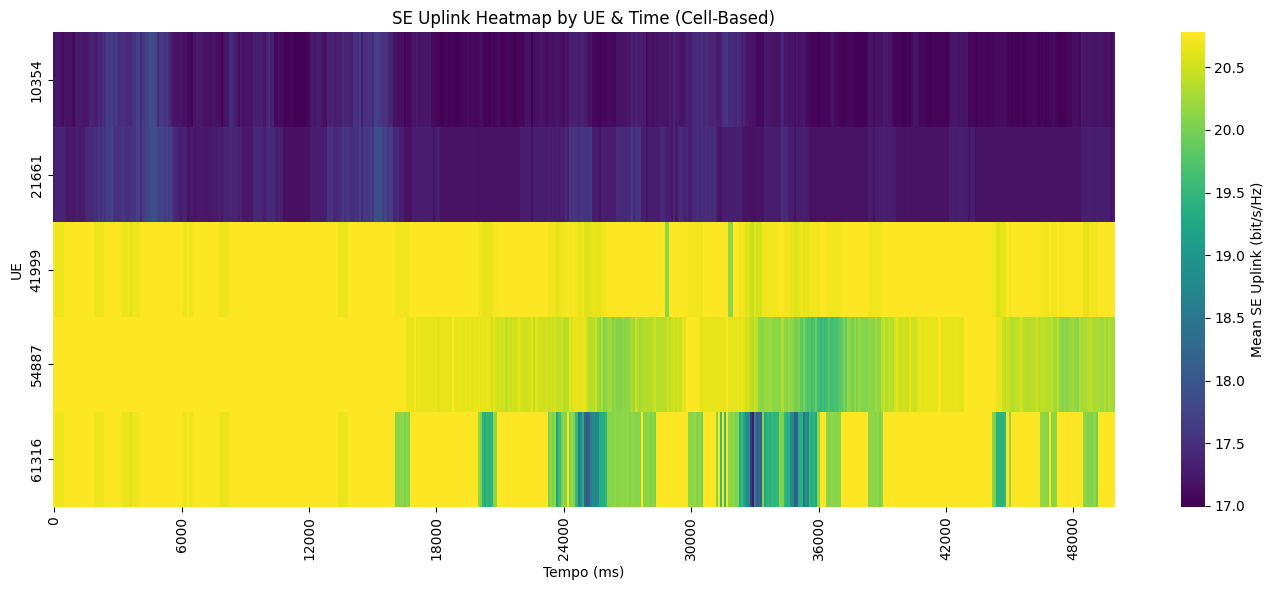

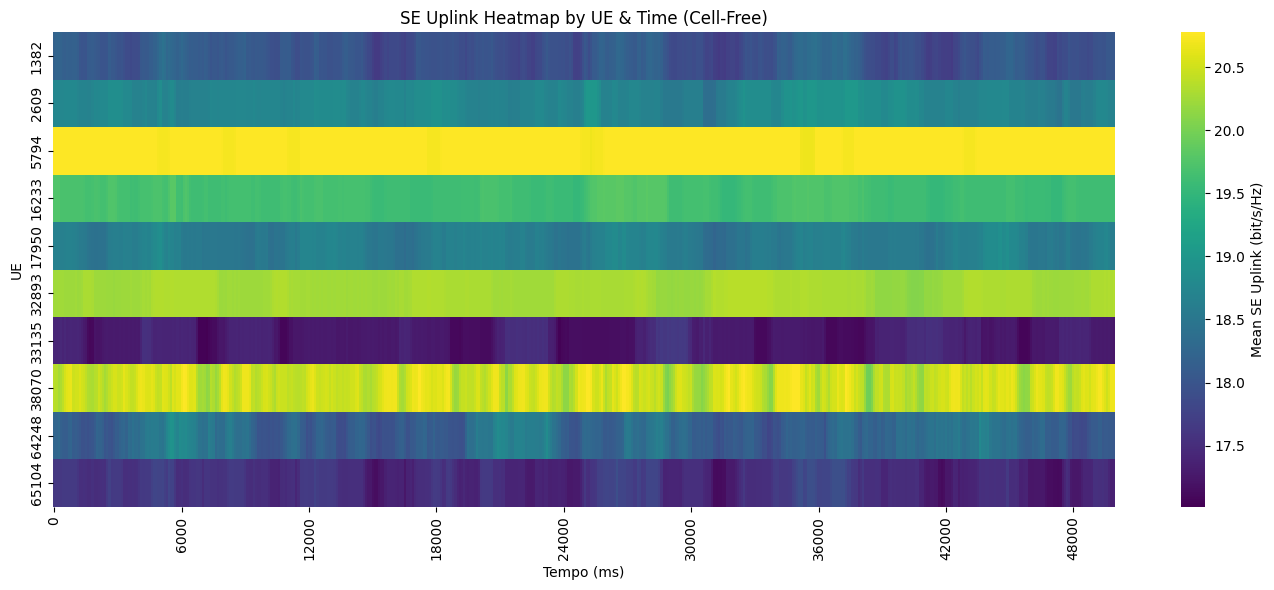

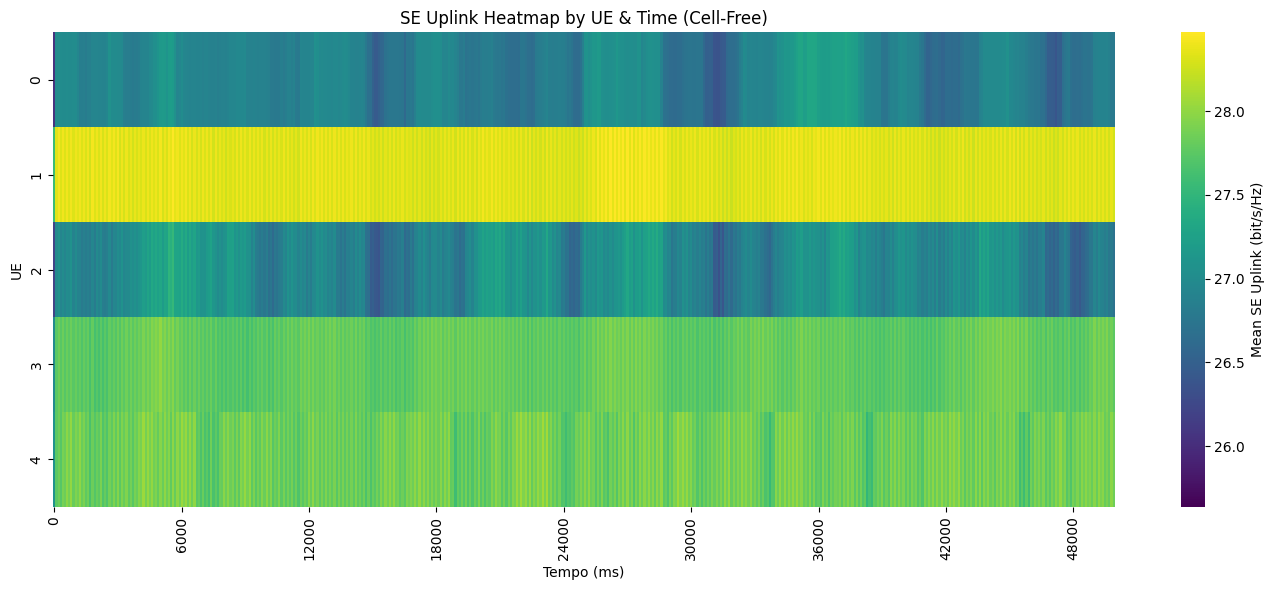

In [52]:
heat_cb = df_cb_5.pivot(index="UE_ID", columns="Time_ms", values="Mean_UL_SE_bit_per_s_Hz")
heat_cf = df_cf_5.pivot(index="UE_ID", columns="Time_ms", values="Mean_UL_SE_bit_per_s_Hz")
heat_cf_aggr = df_cf_5_aggr.pivot(index="UE_ID", columns="Time_ms", values="Mean_UL_SE_bit_per_s_Hz")

# Plot Cell-Based
plt.figure(figsize=(14, 6))
sns.heatmap(heat_cb, cmap="viridis", cbar_kws={'label': 'Mean SE Uplink (bit/s/Hz)'})
plt.title("SE Uplink Heatmap by UE & Time (Cell-Based)")
plt.xlabel("Tempo (ms)")
plt.locator_params(axis="x", nbins=20)
plt.ylabel("UE")
plt.tight_layout()
plt.xlim(0,500)
plt.show()

# Plot Cell-Free
plt.figure(figsize=(14, 6))
sns.heatmap(heat_cf, cmap="viridis", cbar_kws={'label': 'Mean SE Uplink (bit/s/Hz)'})
plt.title("SE Uplink Heatmap by UE & Time (Cell-Free)")
plt.xlabel("Tempo (ms)")
plt.locator_params(axis="x", nbins=20)
plt.ylabel("UE")
plt.xlim(0,500)
plt.tight_layout()
plt.show()

# Plot Cell-Free
plt.figure(figsize=(14, 6))
sns.heatmap(heat_cf_aggr, cmap="viridis", cbar_kws={'label': 'Mean SE Uplink (bit/s/Hz)'})
plt.title("SE Uplink Heatmap by UE & Time (Cell-Free)")
plt.xlabel("Tempo (ms)")
plt.locator_params(axis="x", nbins=20)
plt.ylabel("UE")
plt.xlim(0,500)
plt.tight_layout()
plt.show()

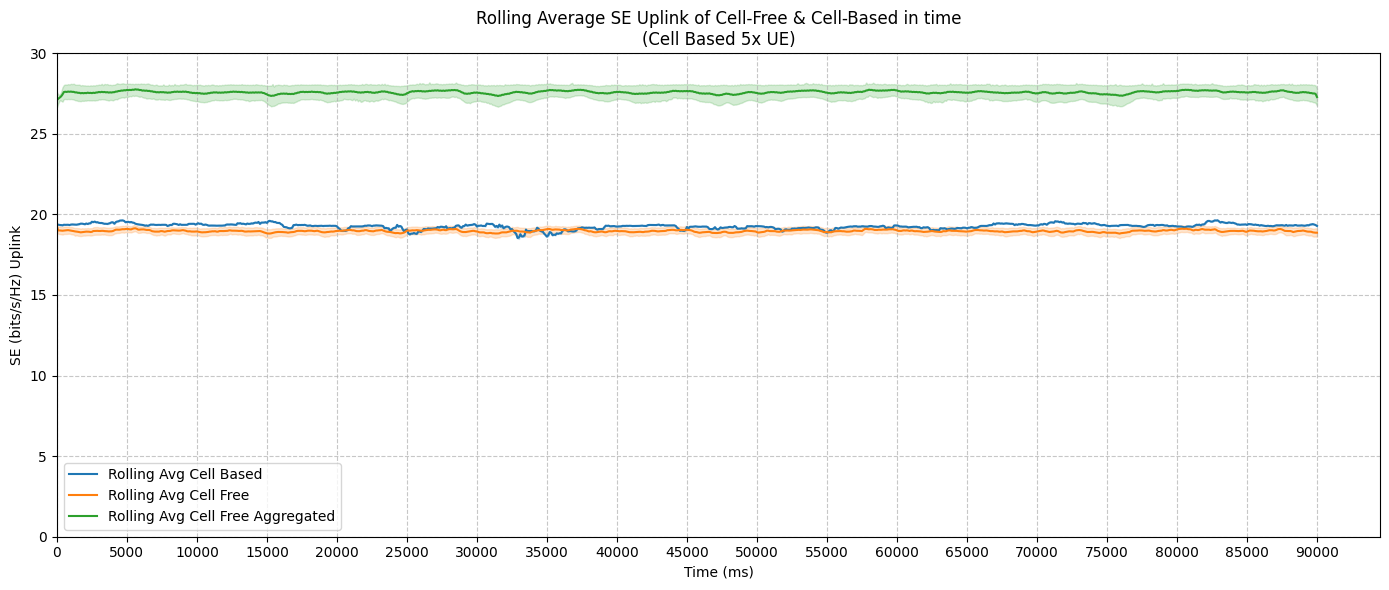

In [53]:
df_cb_5["Mean_UL_SE_bit_per_s_Hz"] = df_cb_5["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cb_5["Rolling Avg (bits/s/Hz)"] = df_cb_5["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

df_cf_5["Mean_UL_SE_bit_per_s_Hz"] = df_cf_5["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cf_5["Rolling Avg (bits/s/Hz)"] = df_cf_5["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

df_cf_5_aggr["Mean_UL_SE_bit_per_s_Hz"] = df_cf_5_aggr["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cf_5_aggr["Rolling Avg (bits/s/Hz)"] = df_cf_5_aggr["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

# Graphic of Throughput and Rolling Average
plt.figure(figsize=(14, 6))
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cb_5, label="Rolling Avg Cell Based")
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cf_5, label="Rolling Avg Cell Free")
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cf_5_aggr, label="Rolling Avg Cell Free Aggregated")
plt.title("Rolling Average SE Uplink of Cell-Free & Cell-Based in time\n(Cell Based 5x UE)")
plt.xlabel("Time (ms)")
plt.ylabel("SE (bits/s/Hz) Uplink")
plt.legend()

plt.grid(True)
plt.ylim(0, 30)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 10X Scenarios

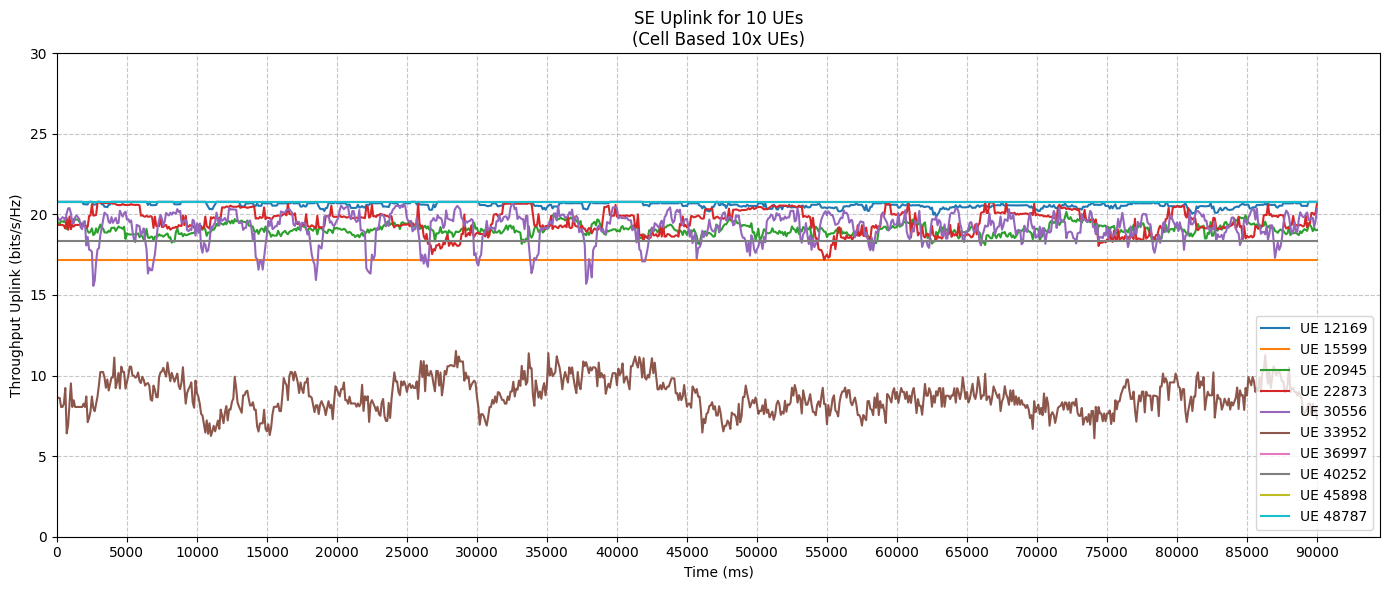

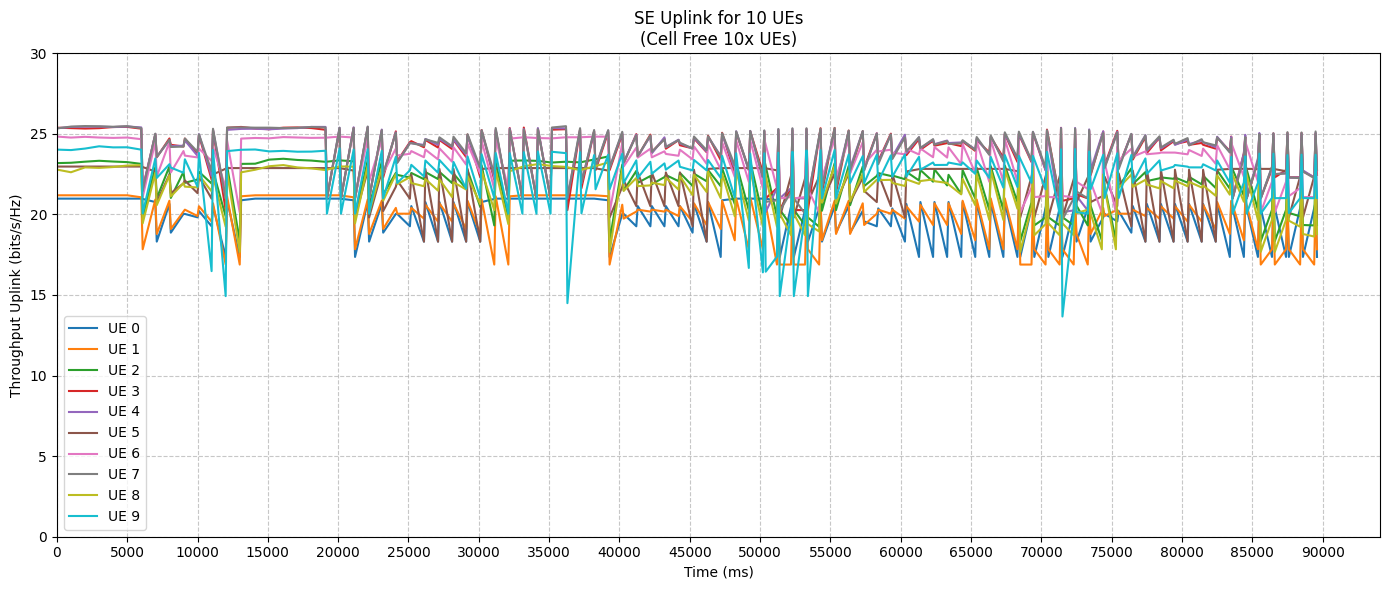

In [ ]:
# Graphic of Throughput and Rolling Average
plt.figure(figsize=(14, 6))
for ue, df in dfs_cb_10.items():
    sns.lineplot(x="Time_ms", y="Mean_UL_SE_bit_per_s_Hz", data=df, label=f"UE {ue}")
plt.title("SE Uplink for 10 UEs\n(Cell Based 10x UEs)")
plt.xlabel("Time (ms)")
plt.ylabel("Throughput Uplink (bits/s/Hz)")
plt.grid(True)
plt.legend()

plt.ylim(0, 30)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Graphic of Throughput and Rolling Average
plt.figure(figsize=(14, 6))
#for ue, df in dfs_cf_10.items():
#    sns.lineplot(x="Time_ms", y="Mean_UL_SE_bit_per_s_Hz", data=df, label=f"UE {ue}")
for ue, df in dfs_cf_10_aggr.items():
    sns.lineplot(x="Time_ms", y="Mean_UL_SE_bit_per_s_Hz", data=df, label=f"UE {ue}")
plt.title("SE Uplink for 10 UEs\n(Cell Free 10x UEs)")
plt.xlabel("Time (ms)")
plt.ylabel("Throughput Uplink (bits/s/Hz)")
plt.grid(True)
plt.legend()

plt.ylim(0, 30)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [57]:
df_cb_10 = pd.read_csv(cb_10x)
df_cf_10 = pd.read_csv(cf_10x)
dfs_cf_10_aggr = pd.read_csv(cf_10x_aggr)

print(df_cb_10["Mean_UL_SE_bit_per_s_Hz"].describe())
print(df_cf_10["Mean_UL_SE_bit_per_s_Hz"].describe())
print(dfs_cf_10_aggr["Mean_UL_SE_bit_per_s_Hz"].describe())

count    9010.000000
mean       18.498316
std         3.476139
min         6.108520
25%        18.324000
50%        19.567956
75%        20.778000
max        20.778000
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64
count    3830.000000
mean       17.551168
std         4.138021
min         2.549000
25%        17.506000
50%        18.487000
75%        20.101366
max        20.778000
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64
count    1736.000000
mean       22.206233
std         2.170868
min        13.661690
25%        20.766790
50%        22.553721
75%        23.935566
max        25.476397
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64


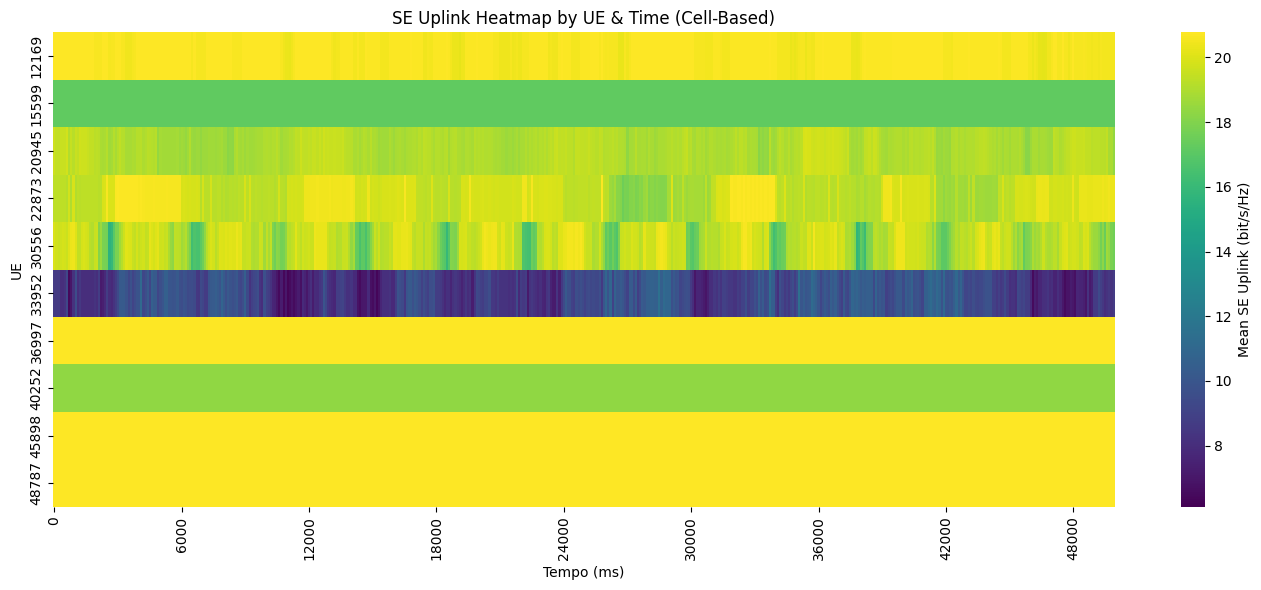

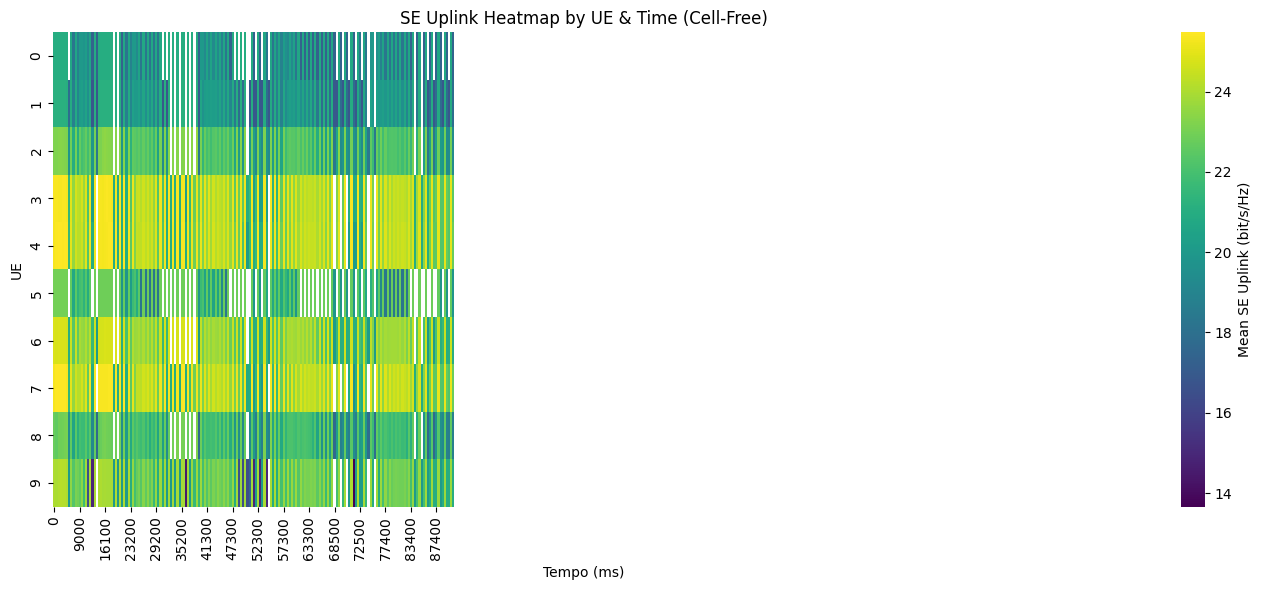

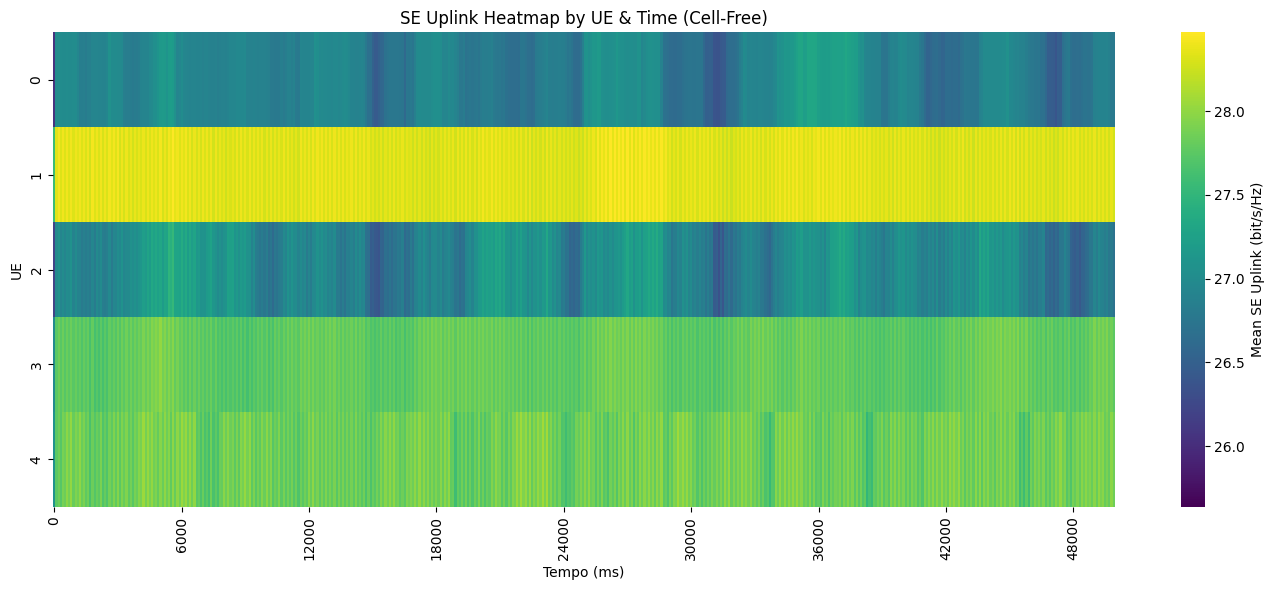

In [65]:

heat_cb = df_cb_10.pivot(index="UE_ID", columns="Time_ms", values="Mean_UL_SE_bit_per_s_Hz")
heat_cf = df_cf_10.pivot(index="UE_ID", columns="Time_ms", values="Mean_UL_SE_bit_per_s_Hz")
heat_cf = dfs_cf_10_aggr.pivot(index="UE_ID", columns="Time_ms", values="Mean_UL_SE_bit_per_s_Hz")

# Plot Cell-Based
plt.figure(figsize=(14, 6))
sns.heatmap(heat_cb, cmap="viridis", cbar_kws={'label': 'Mean SE Uplink (bit/s/Hz)'})
plt.title("SE Uplink Heatmap by UE & Time (Cell-Based)")
plt.xlabel("Tempo (ms)")
plt.locator_params(axis="x", nbins=20)
plt.ylabel("UE")
plt.tight_layout()
plt.xlim(0,500)
plt.show()

# Plot Cell-Free
plt.figure(figsize=(14, 6))
sns.heatmap(heat_cf, cmap="viridis", cbar_kws={'label': 'Mean SE Uplink (bit/s/Hz)'})
plt.title("SE Uplink Heatmap by UE & Time (Cell-Free)")
plt.xlabel("Tempo (ms)")
plt.locator_params(axis="x", nbins=20)
plt.ylabel("UE")
plt.xlim(0,500)
plt.tight_layout()
plt.show()

# Plot Cell-Free
plt.figure(figsize=(14, 6))
sns.heatmap(heat_cf_aggr, cmap="viridis", cbar_kws={'label': 'Mean SE Uplink (bit/s/Hz)'})
plt.title("SE Uplink Heatmap by UE & Time (Cell-Free)")
plt.xlabel("Tempo (ms)")
plt.locator_params(axis="x", nbins=20)
plt.ylabel("UE")
plt.xlim(0,500)
plt.tight_layout()
plt.show()

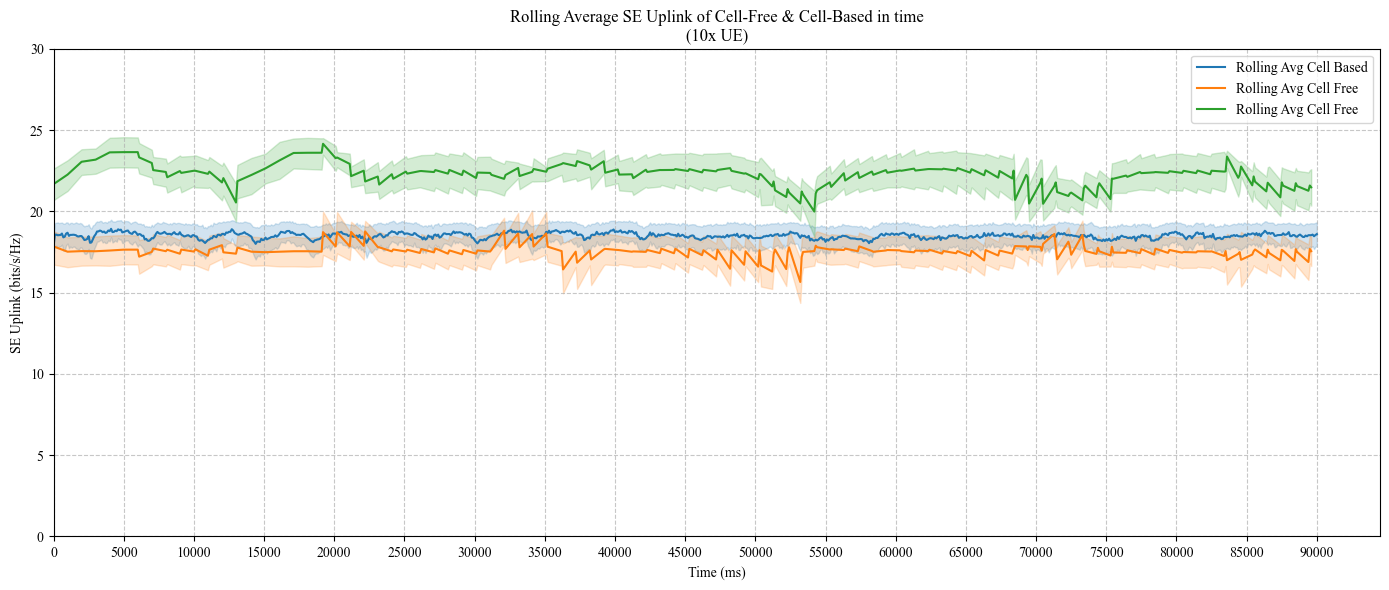

In [ ]:
df_cb_10["Mean_UL_SE_bit_per_s_Hz"] = df_cb_10["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cb_10["Rolling Avg (bits/s/Hz)"] = df_cb_10["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

df_cf_10["Mean_UL_SE_bit_per_s_Hz"] = df_cf_10["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cf_10["Rolling Avg (bits/s/Hz)"] = df_cf_10["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

dfs_cf_10_aggr["SE_total_bit_per_s_Hz"] = dfs_cf_10_aggr["SE_total_bit_per_s_Hz"].round(3)
dfs_cf_10_aggr["Rolling Avg (bits/s/Hz)"] = dfs_cf_10_aggr["SE_total_bit_per_s_Hz"].rolling(window=5).mean()

plt.figure(figsize=(14, 6))
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cb_10, label="Rolling Avg Cell Based")
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cf_10, label="Rolling Avg Cell Free")
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=dfs_cf_10_aggr, label="Rolling Avg Cell Free")
plt.title("Rolling Average SE Uplink of Cell-Free & Cell-Based in time\n(10x UE)")
plt.xlabel("Time (ms)")
plt.ylabel("SE Uplink (bits/s/Hz)")
plt.legend()

plt.grid(True)
plt.ylim(0, 30)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# All Datasets

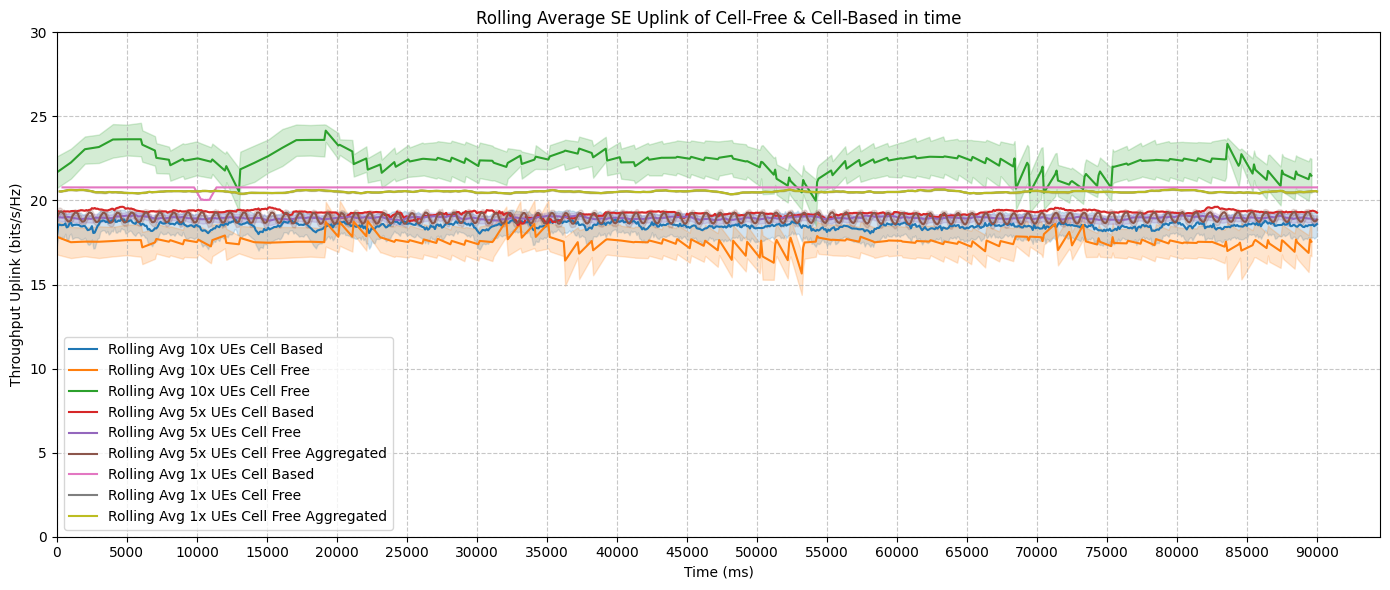

In [67]:
# Round of throughput values to 3 decimal places
df_cb_1["Mean_UL_SE_bit_per_s_Hz"] = df_cb_1["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cb_1["Rolling Avg (bits/s/Hz)"] = df_cb_1["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()
df_cf_1["Mean_UL_SE_bit_per_s_Hz"] = df_cf_1["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cf_1["Rolling Avg (bits/s/Hz)"] = df_cf_1["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()
df_cf_1_aggr["Rolling Avg (bits/s/Hz)"] = df_cf_1_aggr["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

# Round of throughput values to 3 decimal places
df_cb_5["Mean_UL_SE_bit_per_s_Hz"] = df_cb_5["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cb_5["Rolling Avg (bits/s/Hz)"] = df_cb_5["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()
df_cf_5["Mean_UL_SE_bit_per_s_Hz"] = df_cf_5["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cf_5["Rolling Avg (bits/s/Hz)"] = df_cf_5["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()
df_cf_5_aggr["Rolling Avg (bits/s/Hz)"] = df_cf_5["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

# Round of throughput values to 3 decimal places
df_cb_10["Mean_UL_SE_bit_per_s_Hz"] = df_cb_10["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cb_10["Rolling Avg (bits/s/Hz)"] = df_cb_10["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()
df_cf_10["Mean_UL_SE_bit_per_s_Hz"] = df_cf_10["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cf_10["Rolling Avg (bits/s/Hz)"] = df_cf_10["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()
dfs_cf_10_aggr["Rolling Avg (bits/s/Hz)"] = dfs_cf_10_aggr["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

# Graphic of Throughput and Rolling Average
plt.figure(figsize=(14, 6))
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cb_10, label="Rolling Avg 10x UEs Cell Based")
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cf_10, label="Rolling Avg 10x UEs Cell Free")
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=dfs_cf_10_aggr, label="Rolling Avg 10x UEs Cell Free")
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cb_5, label="Rolling Avg 5x UEs Cell Based")
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cf_5, label="Rolling Avg 5x UEs Cell Free")
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cf_5_aggr, label="Rolling Avg 5x UEs Cell Free Aggregated")
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cb_1, label="Rolling Avg 1x UEs Cell Based")
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cf_1, label="Rolling Avg 1x UEs Cell Free")
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cf_1, label="Rolling Avg 1x UEs Cell Free Aggregated")
plt.title("Rolling Average SE Uplink of Cell-Free & Cell-Based in time")
plt.xlabel("Time (ms)")
plt.ylabel("Throughput Uplink (bits/s/Hz)")
plt.legend()

plt.grid(True)
plt.ylim(0, 30)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Barplots

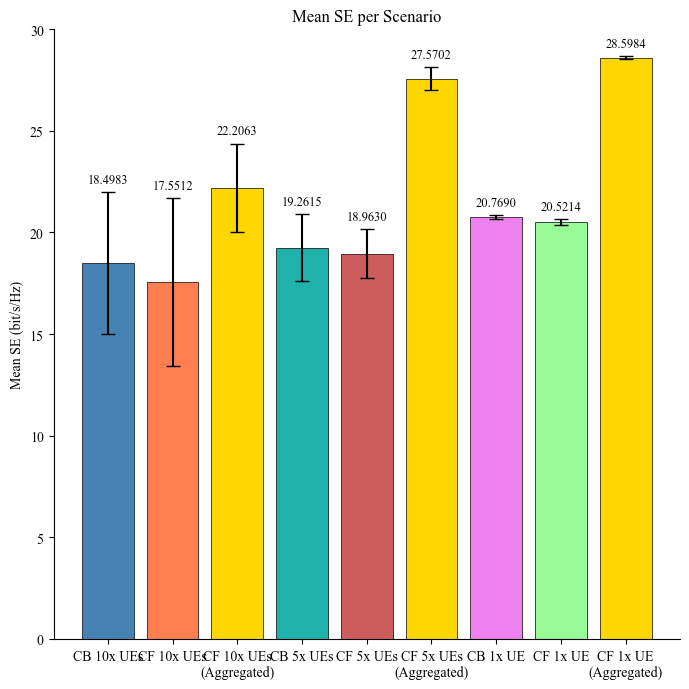

In [73]:

plt.rcParams["font.family"] = "Times New Roman"

# Médias
mean_se_total_1 = df_cb_10['Mean_UL_SE_bit_per_s_Hz'].mean()
mean_se_total_2 = df_cb_5['Mean_UL_SE_bit_per_s_Hz'].mean()
mean_se_total_3 = df_cb_1['Mean_UL_SE_bit_per_s_Hz'].mean()
mean_se_total_4 = df_cf_10['Mean_UL_SE_bit_per_s_Hz'].mean()
mean_se_total_41 = dfs_cf_10_aggr['Mean_UL_SE_bit_per_s_Hz'].mean()
mean_se_total_5 = df_cf_5['Mean_UL_SE_bit_per_s_Hz'].mean()
mean_se_total_51 = df_cf_5_aggr['Mean_UL_SE_bit_per_s_Hz'].mean()
mean_se_total_6 = df_cf_1['Mean_UL_SE_bit_per_s_Hz'].mean()
mean_se_total_61 = df_cf_1_aggr['Mean_UL_SE_bit_per_s_Hz'].mean()

# Desvios padrão
std_se_total_1 = df_cb_10['Mean_UL_SE_bit_per_s_Hz'].std()
std_se_total_2 = df_cb_5['Mean_UL_SE_bit_per_s_Hz'].std()
std_se_total_3 = df_cb_1['Mean_UL_SE_bit_per_s_Hz'].std()
std_se_total_4 = df_cf_10['Mean_UL_SE_bit_per_s_Hz'].std()
std_se_total_41 = dfs_cf_10_aggr['Mean_UL_SE_bit_per_s_Hz'].std()
std_se_total_5 = df_cf_5['Mean_UL_SE_bit_per_s_Hz'].std()
std_se_total_51 = df_cf_5_aggr['Mean_UL_SE_bit_per_s_Hz'].std()
std_se_total_6 = df_cf_1['Mean_UL_SE_bit_per_s_Hz'].std()
std_se_total_61 = df_cf_1_aggr['Mean_UL_SE_bit_per_s_Hz'].std()

# Lista de valores
mean_values = [
    mean_se_total_1,
    mean_se_total_4,
    mean_se_total_41,
    mean_se_total_2,
    mean_se_total_5,
    mean_se_total_51,
    mean_se_total_3,
    mean_se_total_6,
    mean_se_total_61
]

std_values = [
    std_se_total_1,
    std_se_total_4,
    std_se_total_41,
    std_se_total_2,
    std_se_total_5,
    std_se_total_51,
    std_se_total_3,
    std_se_total_6,
    std_se_total_61
]

labels = [
    "CB 10x UEs",
    "CF 10x UEs",
    "CF 10x UEs\n(Aggregated)",
    "CB 5x UEs",
    "CF 5x UEs",
    "CF 5x UEs\n(Aggregated)",
    "CB 1x UE",
    "CF 1x UE",
    "CF 1x UE\n(Aggregated)"
]

colors = ["steelblue", 
          "coral", 
          "gold", # - This color is used for the aggregated CF 10x UEs
          "lightseagreen",
          "indianred",
          "gold", # - This color is used for the aggregated CF 5x UEs
          "violet", 
          "palegreen",
          "gold" # - This color is used for the aggregated CF 1x UE
] 

plt.figure(figsize=(7, 7))
bars = plt.bar(labels, mean_values, color=colors, yerr=std_values, capsize=5,
               edgecolor="black", linewidth=0.5)
plt.title("Mean SE per Scenario")
plt.ylabel("Mean SE (bit/s/Hz)")
plt.ylim(0, 30)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='y')
plt.grid(False)

# Medium values on top of the bars
for i, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + std_values[i] + 0.3,
             f"{mean_values[i]:.4f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

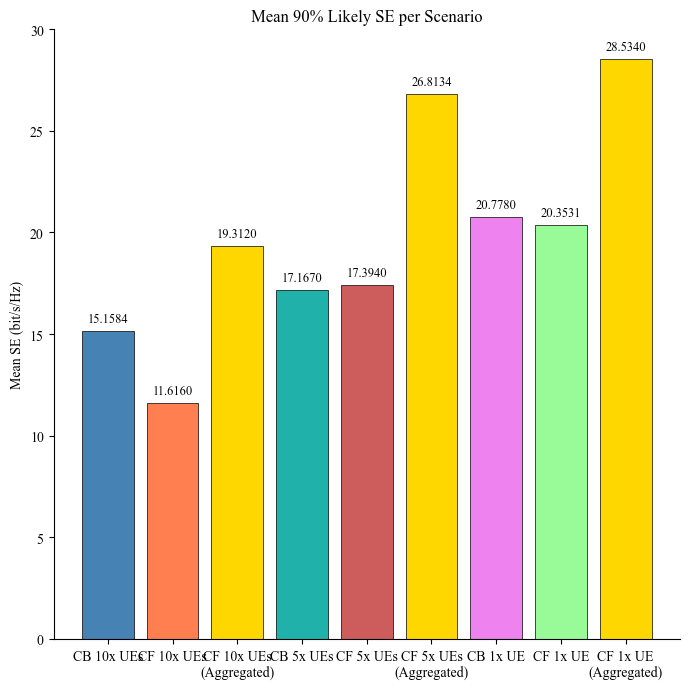

In [78]:

plt.rcParams["font.family"] = "Times New Roman"

# quantis
p10_cf_1 = df_cf_1['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)
p10_cf_1_aggr = df_cf_1_aggr['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)
p10_cf_5 = df_cf_5['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)
p10_cf_5_aggr = df_cf_5_aggr['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)
p10_cf_10 = df_cf_10['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)
p10_cf_10_aggr = dfs_cf_10_aggr['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)
p10_cb_1 = df_cb_1['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)
p10_cb_5 = df_cb_5['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)
p10_cb_10 = df_cb_10['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)

# Lista de valores
mean_values = [
    p10_cb_10,
    p10_cf_10,
    p10_cf_10_aggr,
    p10_cb_5,
    p10_cf_5,
    p10_cf_5_aggr,
    p10_cb_1,
    p10_cf_1,
    p10_cf_1_aggr
]

labels = [
    "CB 10x UEs",
    "CF 10x UEs",
    "CF 10x UEs\n(Aggregated)",
    "CB 5x UEs",
    "CF 5x UEs",
    "CF 5x UEs\n(Aggregated)",
    "CB 1x UE",
    "CF 1x UE",
    "CF 1x UE\n(Aggregated)"
]

colors = ["steelblue", 
          "coral", 
          "gold", # - This color is used for the aggregated CF 10x UEs
          "lightseagreen",
          "indianred",
          "gold", # - This color is used for the aggregated CF 5x UEs
          "violet", 
          "palegreen",
          "gold" # - This color is used for the aggregated CF 1x UE
] 

plt.figure(figsize=(7, 7))
bars = plt.bar(labels, mean_values, color=colors, capsize=5,
               edgecolor="black", linewidth=0.5)
plt.title("Mean 90% Likely SE per Scenario")
plt.ylabel("Mean SE (bit/s/Hz)")
plt.ylim(0, 30)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='y')
plt.grid(False)

# Medium values on top of the bars
for i, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.3,
             f"{mean_values[i]:.4f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

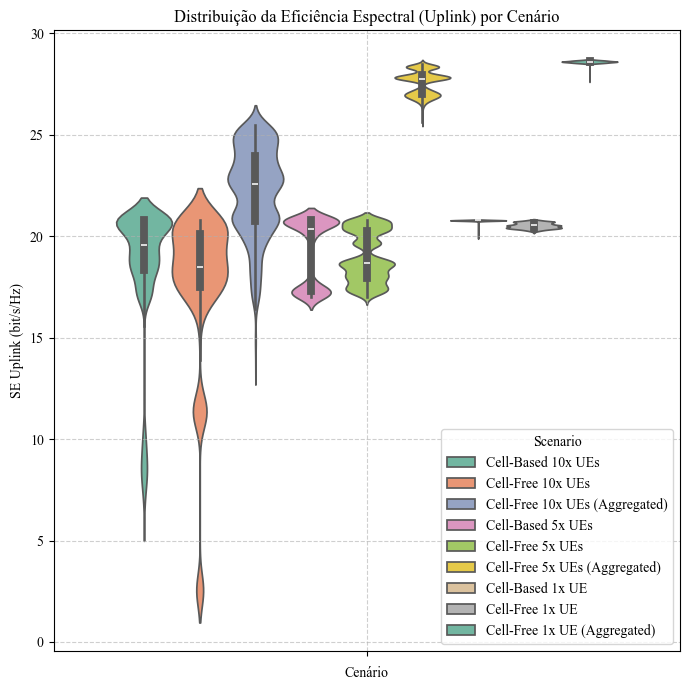

In [97]:
df_cb_10["Scenario"] = "Cell-Based 10x UEs"
df_cf_10["Scenario"] = "Cell-Free 10x UEs"
dfs_cf_10_aggr["Scenario"] = "Cell-Free 10x UEs (Aggregated)"
df_cb_5["Scenario"] = "Cell-Based 5x UEs"
df_cf_5["Scenario"] = "Cell-Free 5x UEs"
df_cf_5_aggr["Scenario"] = "Cell-Free 5x UEs (Aggregated)"
df_cb_1["Scenario"] = "Cell-Based 1x UE"
df_cf_1["Scenario"] = "Cell-Free 1x UE"
df_cf_1_aggr["Scenario"] = "Cell-Free 1x UE (Aggregated)"

df_all = pd.concat([df_cb_10, df_cf_10, dfs_cf_10_aggr, df_cb_5, df_cf_5, df_cf_5_aggr, df_cb_1, df_cf_1, df_cf_1_aggr], ignore_index=True)

plt.figure(figsize=(7,7))
# Tbm pode ser feito com sns.boxplot
sns.violinplot(
    y="Mean_UL_SE_bit_per_s_Hz",
    data=df_all,
    hue="Scenario",
    palette="Set2"
)
plt.title("Distribuição da Eficiência Espectral (Uplink) por Cenário")
plt.xlabel("Cenário")
plt.ylabel("SE Uplink (bit/s/Hz)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


C:\Users\Ana Gouveia\AppData\Local\Temp\ipykernel_7196\260938304.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


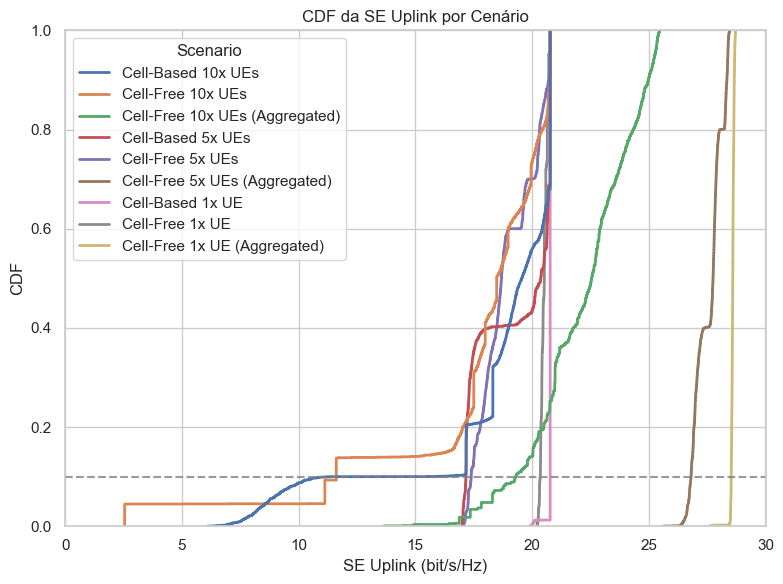

In [191]:
df_cb_10["Scenario"] = "Cell-Based 10x UEs"
df_cf_10["Scenario"] = "Cell-Free 10x UEs"
dfs_cf_10_aggr["Scenario"] = "Cell-Free 10x UEs (Aggregated)"
df_cb_5["Scenario"] = "Cell-Based 5x UEs"
df_cf_5["Scenario"] = "Cell-Free 5x UEs"
df_cf_5_aggr["Scenario"] = "Cell-Free 5x UEs (Aggregated)"
df_cb_1["Scenario"] = "Cell-Based 1x UE"
df_cf_1["Scenario"] = "Cell-Free 1x UE"
df_cf_1_aggr["Scenario"] = "Cell-Free 1x UE (Aggregated)"

order = ["Cell-Based 10x UEs"
         , "Cell-Free 10x UEs"
         , "Cell-Free 10x UEs (Aggregated)"
         , "Cell-Based 5x UEs"
         , "Cell-Free 5x UEs"
         , "Cell-Free 5x UEs (Aggregated)"
         , "Cell-Based 1x UE"
         , "Cell-Free 1x UE"
         , "Cell-Free 1x UE (Aggregated)"
]

dfs_to_plot = [
    df_cb_10[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
    df_cf_10[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
    dfs_cf_10_aggr[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
    df_cb_5[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
    df_cf_5[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
    df_cf_5_aggr[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
    df_cb_1[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
    df_cf_1[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
    df_cf_1_aggr[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
]
df_all = pd.concat(dfs_to_plot, ignore_index=True)
df_all = df_all.dropna(subset=["Mean_UL_SE_bit_per_s_Hz"]).copy()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,6))
plt.legend(loc="lower right")
ax = sns.ecdfplot(
    data=df_all,
    x="Mean_UL_SE_bit_per_s_Hz",
    hue="Scenario",
    hue_order=order,
    label = order,
    linewidth=2 
)
y_ref = 0.1
line = ax.axhline(
    y_ref,
    ls="--",
    lw=1.5,
    color="gray",
    alpha=0.8,
    label="90%-likely (y=0.1)"
)

plt.title("CDF da SE Uplink por Cenário")
plt.xlabel("SE Uplink (bit/s/Hz)")
plt.ylabel("CDF")
plt.xlim(0, None)  # opcional: por ex. (10, 30)
plt.tight_layout()
plt.show()


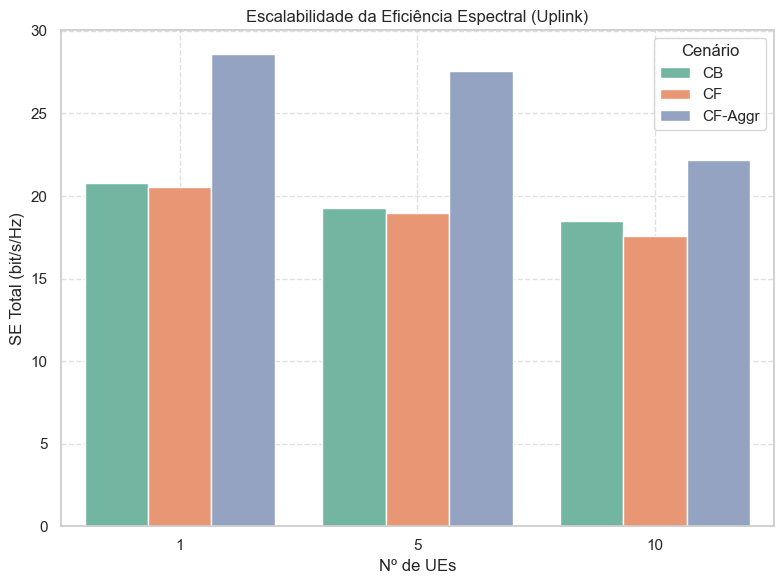

In [ ]:
data = {
    "Nº de UEs": [1, 1, 1, 5, 5, 5, 10, 10, 10],
    "Cenário": ["CB", "CF", "CF-Aggr",
                "CB", "CF", "CF-Aggr",
                "CB", "CF", "CF-Aggr"],
    "SE_total": [
        df_cb_1["Mean_UL_SE_bit_per_s_Hz"].mean(),
        df_cf_1["Mean_UL_SE_bit_per_s_Hz"].mean(),
        df_cf_1_aggr["Mean_UL_SE_bit_per_s_Hz"].mean(),
        df_cb_5["Mean_UL_SE_bit_per_s_Hz"].mean(),
        df_cf_5["Mean_UL_SE_bit_per_s_Hz"].mean(),
        df_cf_5_aggr["Mean_UL_SE_bit_per_s_Hz"].mean(),
        df_cb_10["Mean_UL_SE_bit_per_s_Hz"].mean(),
        df_cf_10["Mean_UL_SE_bit_per_s_Hz"].mean(),
        dfs_cf_10_aggr["Mean_UL_SE_bit_per_s_Hz"].mean()
    ]
}

df_plot = pd.DataFrame(data)

# Plot
plt.figure(figsize=(8,6))
sns.barplot(
    x="Nº de UEs", 
    y="SE_total", 
    hue="Cenário", 
    data=df_plot, 
    palette="Set2"
)

plt.title("Escalabilidade da Eficiência Espectral (Uplink)")
plt.ylabel("SE Total (bit/s/Hz)")
plt.xlabel("Nº de UEs")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


C:\Users\Ana Gouveia\AppData\Local\Temp\ipykernel_7196\2132510658.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: jain_index(g.groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"].mean()))
C:\Users\Ana Gouveia\AppData\Local\Temp\ipykernel_7196\2132510658.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: jain_index(g.groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"].mean()))
C:\Users\Ana Gou

  Scenario  UEs      Jain  Jain_mean_t    Jain_std_t
0       CB    1  1.000000     1.000000  0.000000e+00
3       CB    5  0.992954     0.992803  9.101852e-04
6       CB   10  0.966573     0.965942  5.710433e-03
1       CF    1  0.999969     0.999961  3.131152e-05
4       CF    5  0.996050     0.996008  3.045905e-04
7       CF   10  0.948333     0.948564  1.647933e-02
2  CF-Aggr    1  1.000000     1.000000  1.281975e-17
5  CF-Aggr    5  0.999597     0.999582  1.136258e-04
8  CF-Aggr   10  0.995308     0.994162  3.175550e-03


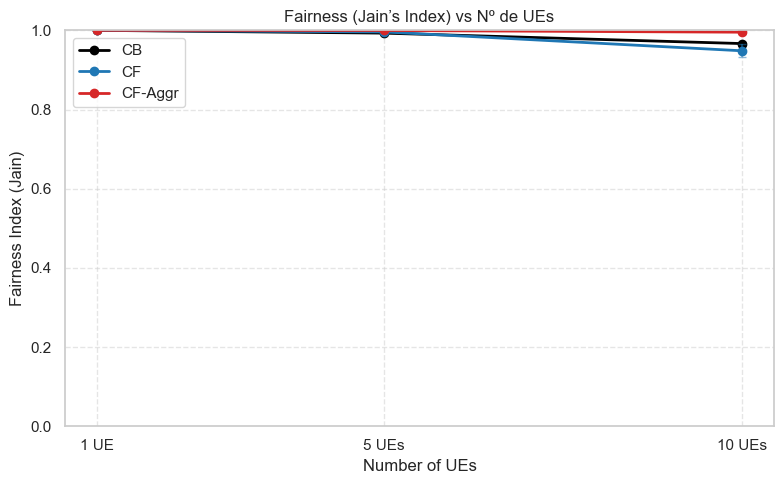

In [ ]:
# --- helpers ---------------------------------------------------------------
def to_df(x):
    """Se vier um dict de DFs por UE, achata para um único DataFrame."""
    if isinstance(x, dict):
        return pd.concat(x, names=["UE_ID"]).reset_index(level=0).reset_index(drop=True)
    return x.copy()

def jain_index(x):
    x = np.asarray(x, dtype=float)
    if len(x) == 0 or np.isclose((x**2).sum(), 0):
        return np.nan
    return (x.sum()**2) / (len(x) * (x**2).sum())

def fairness_for_df(df):
    """Jain sobre as *médias por UE* (fairness entre utilizadores)."""
    per_ue_mean = (df.groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"]
                     .mean()
                     .dropna()
                     .values)
    return jain_index(per_ue_mean)

def fairness_time_stats(df):
    """(opcional) Jain por instante -> média e std no tempo (para erro/banda)."""
    per_t = (df.groupby("Time_ms")
               .apply(lambda g: jain_index(g.groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"].mean()))
               .dropna())
    return per_t.mean(), per_t.std()

CB_1   = to_df(df_cb_1)
CF_1   = to_df(df_cf_1)
CFA_1  = to_df(df_cf_1_aggr)
CB_5   = to_df(df_cb_5)
CF_5   = to_df(df_cf_5)
CFA_5  = to_df(df_cf_5_aggr)
CB_10  = to_df(df_cb_10)
CF_10  = to_df(df_cf_10)
CFA_10 = to_df(dfs_cf_10_aggr) 

datasets = {
    ("CB",      1): CB_1,   ("CF",      1): CF_1,   ("CF-Aggr", 1): CFA_1,
    ("CB",      5): CB_5,   ("CF",      5): CF_5,   ("CF-Aggr", 5): CFA_5,
    ("CB",     10): CB_10,  ("CF",     10): CF_10,  ("CF-Aggr",10): CFA_10,
}

# --- tabela com Jain por cenário e nº de UEs --------------------------------
rows = []
for (scenario, nues), df in datasets.items():
    if df.empty: 
        continue
    j = fairness_for_df(df)
    mu, sd = fairness_time_stats(df)  # opcional (erro temporal)
    rows.append({"Scenario": scenario, "UEs": nues, "Jain": j, "Jain_mean_t": mu, "Jain_std_t": sd})

fair = pd.DataFrame(rows).sort_values(["Scenario","UEs"])
print(fair)

# --- plot tipo o do paper: linhas por cenário vs nº de UEs ------------------
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,5))

palette = {"CB":"black", "CF":"tab:blue", "CF-Aggr":"tab:red"}

for scen, sub in fair.groupby("Scenario"):
    sub = sub.sort_values("UEs")
    # linha principal (Jain calculado sobre médias por UE)
    plt.plot(sub["UEs"], sub["Jain"], marker="o", lw=2, label=scen, color=palette.get(scen, None))
    # (opcional) barras de erro usando variação temporal do Jain
    if sub["Jain_std_t"].notna().any():
        plt.errorbar(sub["UEs"], sub["Jain_mean_t"], yerr=sub["Jain_std_t"],
                     fmt="none", ecolor=palette.get(scen, None), alpha=0.5, capsize=3)

plt.ylim(0, 1.0)
plt.title("Fairness (Jain’s Index) vs Nº de UEs")
plt.xlabel("Number of UEs")
plt.ylabel("Fairness Index (Jain)")
plt.xticks([1,5,10], ["1 UE","5 UEs","10 UEs"])
plt.legend(title=None, loc="best")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

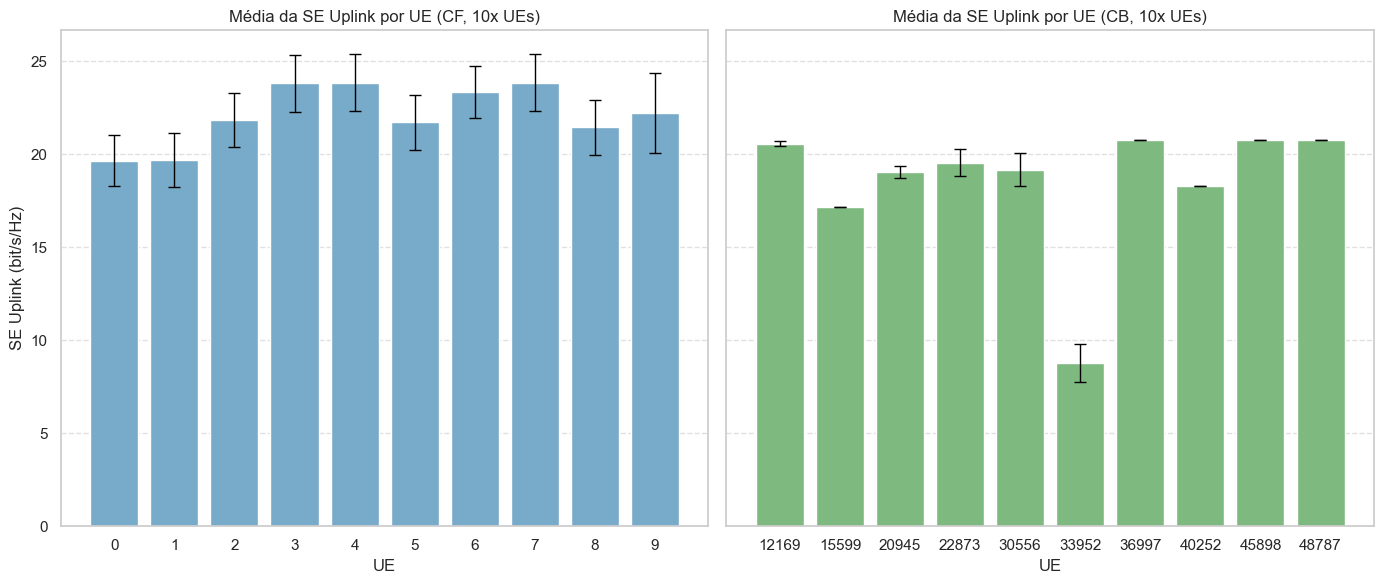

In [179]:
# CF 10x UEs
df_means_cf = (dfs_cf_10_aggr
            .groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"]
            .agg(mean="mean", std="std")
            .reset_index())

# CB 10x UEs
df_means_cb = (df_cb_10
            .groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"]
            .agg(mean="mean", std="std")
            .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# --- Plot CF ---
ax1 = sns.barplot(
    data=df_means_cf,
    x="UE_ID",
    y="mean",
    errorbar=None,
    color="#6baed6",
    ax=axes[0]
)
ax1.errorbar(
    x=np.arange(len(df_means_cf)),
    y=df_means_cf["mean"],
    yerr=df_means_cf["std"],
    fmt="none",
    ecolor="black",
    elinewidth=1,
    capsize=4,
)
ax1.set_title("Média da SE Uplink por UE (CF, 10x UEs)")
ax1.set_xlabel("UE")
ax1.set_ylabel("SE Uplink (bit/s/Hz)")
ax1.grid(True, linestyle="--", alpha=0.6, axis="y")

# --- Plot CB ---
ax2 = sns.barplot(
    data=df_means_cb,
    x="UE_ID",
    y="mean",
    errorbar=None,
    color="#74c476",
    ax=axes[1]
)
ax2.errorbar(
    x=np.arange(len(df_means_cb)),
    y=df_means_cb["mean"],
    yerr=df_means_cb["std"],
    fmt="none",
    ecolor="black",
    elinewidth=1,
    capsize=4,
)
ax2.set_title("Média da SE Uplink por UE (CB, 10x UEs)")
ax2.set_xlabel("UE")
ax2.set_ylabel("")
ax2.grid(True, linestyle="--", alpha=0.6, axis="y")

plt.tight_layout()
plt.show()


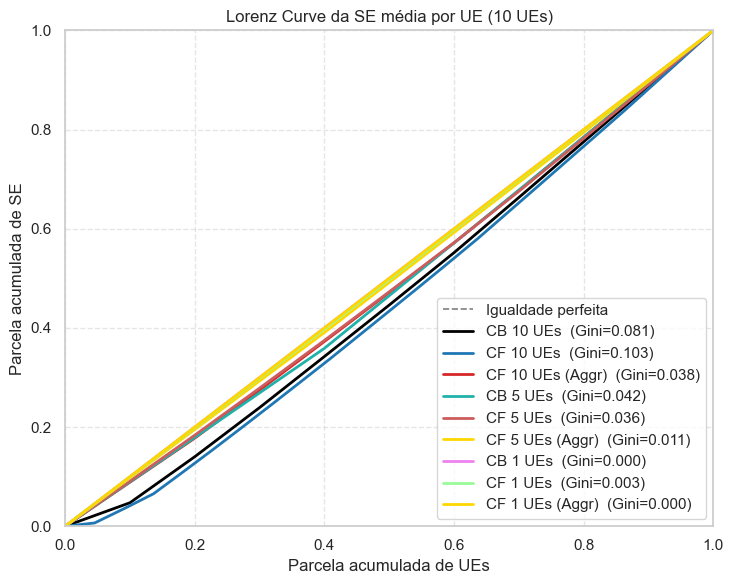

In [182]:
# --- helpers ----------------------------------------------------------------
def to_df(x):
    """Se vier um dict {UE_ID: df}, achata para um único DataFrame."""
    if isinstance(x, dict):
        return pd.concat(x, names=["UE_ID"]).reset_index(level=0).reset_index(drop=True)
    return x.copy()

def normalize_se_col(df):
    """Garante que existe 'Mean_UL_SE_bit_per_s_Hz'."""
    df = df.copy()
    if "Mean_UL_SE_bit_per_s_Hz" not in df.columns and "SE_total_bit_per_s_Hz" in df.columns:
        df.rename(columns={"SE_total_bit_per_s_Hz":"Mean_UL_SE_bit_per_s_Hz"}, inplace=True)
    return df

def per_ue_mean_se(df):
    """SE MÉDIA por UE (fairness entre utilizadores)."""
    df = normalize_se_col(to_df(df))
    se = (df.groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"]
            .mean()
            .clip(lower=0)              # garantir não-negativo
            .sort_values()
            .to_numpy())
    return se

def gini_from_values(x):
    """Índice de Gini para vetor não-negativo (0=perfeito, 1=desigualdade total)."""
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return np.nan
    if np.allclose(x, 0):
        return 0.0
    x = np.sort(x)
    n = x.size
    cumx = np.cumsum(x)
    # fórmula vetorizada robusta
    g = (n + 1 - 2 * (cumx / cumx[-1]).sum()) / n
    return float(g)

def lorenz_curve_points(x):
    """Devolve (pop_share, se_share) já incluindo o (0,0) e o (1,1)."""
    x = np.asarray(x, dtype=float)
    x = np.clip(x, 0, None)
    x = np.sort(x)
    n = x.size
    if n == 0 or np.allclose(x.sum(), 0):
        return np.array([0,1]), np.array([0,1])
    cumx = np.cumsum(x)
    se_share = np.concatenate([[0], cumx / cumx[-1]])
    pop_share = np.linspace(0, 1, n+1)
    return pop_share, se_share

# --- dados: escolhe os de 10 UEs (ajusta nomes conforme os teus objetos) ----
CB_10  = df_cb_10
CF_10  = df_cf_10
CFA_10 = dfs_cf_10_aggr

CB_5  = df_cb_5
CF_5  = df_cf_5
CFA_5 = df_cf_5_aggr

CB_1  = df_cb_1
CF_1  = df_cf_1
CFA_1 = df_cf_1_aggr

datasets = {
    "CB 10 UEs":  CB_10,
    "CF 10 UEs":  CF_10,
    "CF 10 UEs (Aggr)": CFA_10,
    "CB 5 UEs":  CB_5,
    "CF 5 UEs":  CF_5,
    "CF 5 UEs (Aggr)": CFA_5,
    "CB 1 UEs":  CB_1,
    "CF 1 UEs":  CF_1,
    "CF 1 UEs (Aggr)": CFA_1,
}

# --- calcular SE por UE, Gini e pontos da Lorenz ----------------------------
curves = {}
for name, df in datasets.items():
    se_vec = per_ue_mean_se(df)
    pop_share, se_share = lorenz_curve_points(se_vec)
    gini = gini_from_values(se_vec)
    curves[name] = {"pop": pop_share, "se": se_share, "gini": gini, "n": len(se_vec)}

# --- plot -------------------------------------------------------------------
plt.figure(figsize=(7.5,6))
# linha de igualdade perfeita
plt.plot([0,1], [0,1], ls="--", lw=1.2, color="gray", label="Igualdade perfeita")

colors = {"CB 10 UEs":"black", "CF 10 UEs":"tab:blue", "CF 10 UEs (Aggr)":"tab:red", "CB 5 UEs":"lightseagreen",
          "CF 5 UEs":"indianred", "CF 5 UEs (Aggr)":"gold", "CB 1 UEs":"violet", "CF 1 UEs":"palegreen", "CF 1 UEs (Aggr)":"gold"}
for name, c in curves.items():
    plt.plot(c["pop"], c["se"], lw=2, label=f"{name}  (Gini={c['gini']:.3f})", color=colors.get(name, None))
    # pontos nas extremidades (opcional)
    plt.scatter([c["pop"][-1]], [c["se"][-1]], s=12, color=colors.get(name, None))

plt.title("Lorenz Curve da SE média por UE (10 UEs)")
plt.xlabel("Parcela acumulada de UEs")
plt.ylabel("Parcela acumulada de SE")
plt.xlim(0,1); plt.ylim(0,1)
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## Requirements

|                | VM RAN    | VM CN     | VM UEs      |  VM FlexRIC | 
|--------------  |-----------|-----------|-------------|-------------|
| CPU            | 12        | 2         | 14          | 4           | 
| RAM (GiB)      | 24        | 2         | 20          | 6           | 
| Storage  (GiB) | 76        | 25        | 50          | 50          | 
